# DL RV Experiments Framework

Modular notebook scaffold to test multiple datasets, feature modes, and model architectures.

Design goals:
- Keep reusable logic in generic functions.
- Keep optional transformations (e.g., add `ccf_vrad`, hybrid residual target) as separate plug-in functions.
- Use registries so adding new modes/models requires minimal changes.


In [42]:
from pathlib import Path
from dataclasses import dataclass
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [43]:
# ============================
# Global Config
# ============================

BASE_DIR = Path.cwd()

# Add as many files as needed later.
DATASETS = [
    #{
    #    "name": "step_0p1",
    #    "path": BASE_DIR / "saved_spectra" / "random_2000ccf_with_rv.csv",
    #    "vrad_min": -15.0,
    #    "vrad_max": 15.0,
    #    "vrad_step": 0.1,
    #},
    # Example for finer grid:
    {
         "name": "step_0p01",
         "path": BASE_DIR / "saved_spectra" / "random_3000ccf_with_rv_001step.csv",
         "vrad_min": -15.0,
         "vrad_max": 15.0,
         "vrad_step": 0.01,
     },
]

RUN_CFG = {
    "target_col": "rv_shift_ms",
    "sample_col": "sample_index",
    "feature_prefix": "ccf_",
    "split": {"test_size": 0.30, "dev_size_from_tmp": 0.50, "random_state": SEED},
    "train": {
        "epochs": 35,
        "batch_size": 64,
        "patience": 15,
        "verbose": 1,
    },
    "baseline": {
        "method": "gaussian",  # gaussian | parabola
        "window_half": 6,
    },

}




In [44]:
# ============================
# Generic Core Functions
# ============================

def reg_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2 = r2_score(y_true, y_pred)
    return {"mae": mae, "rmse": rmse, "r2": r2}

def load_dataset(dataset_cfg, run_cfg):
    path = Path(dataset_cfg["path"])
    if not path.exists():
        raise FileNotFoundError(f"Dataset not found: {path}")

    df = pd.read_csv(path)
    target_col = run_cfg["target_col"]
    sample_col = run_cfg["sample_col"]
    feature_prefix = run_cfg["feature_prefix"]

    required = {target_col, sample_col}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns in {path.name}: {missing}")

    ccf_cols = [c for c in df.columns if c.startswith(feature_prefix)]
    if not ccf_cols:
        ccf_cols = [
            c for c in df.select_dtypes(include=[np.number]).columns
            if c not in {target_col, sample_col}
        ]
    if not ccf_cols:
        raise ValueError(f"No feature columns found in {path.name}")

    X_ccf = df[ccf_cols].to_numpy(dtype=np.float32)
    y = pd.to_numeric(df[target_col], errors="coerce").to_numpy(dtype=np.float32)
    idx = pd.to_numeric(df[sample_col], errors="coerce").to_numpy(dtype=np.int64)

    if np.isnan(y).any():
        raise ValueError(f"NaN found in target column: {target_col}")

    vrad = np.arange(
        dataset_cfg["vrad_min"],
        dataset_cfg["vrad_max"] + dataset_cfg["vrad_step"],
        dataset_cfg["vrad_step"],
        dtype=np.float32,
    )
    if len(vrad) != X_ccf.shape[1]:
        raise ValueError(
            f"vrad length ({len(vrad)}) != feature bins ({X_ccf.shape[1]}) for {dataset_cfg['name']}"
        )

    return {
        "df": df,
        "X_ccf": X_ccf,
        "y_true": y,
        "sample_index": idx,
        "ccf_cols": ccf_cols,
        "ccf_vrad": vrad,
        "dataset_name": dataset_cfg["name"],
        "dataset_path": str(path),
    }

def split_with_extras(X, y_model, y_true, sample_idx, extras, split_cfg):
    arrays = [X, y_model, y_true, sample_idx] + [extras[k] for k in extras.keys()]

    part = train_test_split(
        *arrays,
        test_size=split_cfg["test_size"],
        random_state=split_cfg["random_state"],
        shuffle=True,
    )

    # train_test_split returns alternating outputs: arr1_train, arr1_test, arr2_train, arr2_test, ...
    train_block = part[0::2]
    tmp_block = part[1::2]

    part2 = train_test_split(
        *tmp_block,
        test_size=split_cfg["dev_size_from_tmp"],
        random_state=split_cfg["random_state"],
        shuffle=True,
    )
    dev_block = part2[0::2]
    test_block = part2[1::2]

    names = ["X", "y_model", "y_true", "sample_index"] + [f"extra::{k}" for k in extras.keys()]
    out = {"train": {}, "dev": {}, "test": {}}
    for i, name in enumerate(names):
        out["train"][name] = train_block[i]
        out["dev"][name] = dev_block[i]
        out["test"][name] = test_block[i]
    return out

def fit_transform_X(X_train, X_dev, X_test, input_kind):
    if input_kind == "tabular":
        scaler = StandardScaler()
        return (
            scaler.fit_transform(X_train),
            scaler.transform(X_dev),
            scaler.transform(X_test),
            {"x_scaler": scaler},
        )

    if input_kind == "sequence":
        n_channels = X_train.shape[-1]
        scalers = []
        Xtr = X_train.copy()
        Xdv = X_dev.copy()
        Xte = X_test.copy()
        for ch in range(n_channels):
            sc = StandardScaler()
            Xtr_ch = Xtr[:, :, ch]
            Xdv_ch = Xdv[:, :, ch]
            Xte_ch = Xte[:, :, ch]
            Xtr[:, :, ch] = sc.fit_transform(Xtr_ch)
            Xdv[:, :, ch] = sc.transform(Xdv_ch)
            Xte[:, :, ch] = sc.transform(Xte_ch)
            scalers.append(sc)
        return Xtr, Xdv, Xte, {"x_scalers": scalers}

    raise ValueError(f"Unsupported input_kind: {input_kind}")

def fit_transform_y(y_train, y_dev, y_test):
    sc = StandardScaler()
    ytr = sc.fit_transform(y_train.reshape(-1, 1)).ravel()
    ydv = sc.transform(y_dev.reshape(-1, 1)).ravel()
    yte = sc.transform(y_test.reshape(-1, 1)).ravel()
    return ytr, ydv, yte, sc

def train_model(model, X_train, y_train_s, X_dev, y_dev_s, run_cfg):
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=run_cfg["train"]["patience"],
            restore_best_weights=True,
        )
    ]
    history = model.fit(
        X_train,
        y_train_s,
        validation_data=(X_dev, y_dev_s),
        epochs=run_cfg["train"]["epochs"],
        batch_size=run_cfg["train"]["batch_size"],
        callbacks=callbacks,
        verbose=run_cfg["train"]["verbose"],
    )
    return history

def invert_y(y_pred_s, y_scaler):
    return y_scaler.inverse_transform(y_pred_s.reshape(-1, 1)).ravel()



In [45]:
# ============================
# Optional Baseline/Fitter Functions
# ============================

def _gaussian_absorption(v, amp, mu, sigma, cont):
    return cont - amp * np.exp(-0.5 * ((v - mu) / sigma) ** 2)

def estimate_rv_parabola_ms(ccf_vec, vrad, window_half=1):
    idx0 = int(np.argmin(ccf_vec))
    lo = max(0, idx0 - window_half)
    hi = min(len(vrad), idx0 + window_half + 1)
    x = vrad[lo:hi].astype(np.float64)
    y = ccf_vec[lo:hi].astype(np.float64)
    if len(x) < 3:
        return float(vrad[idx0] * 1000.0)
    a, b, _ = np.polyfit(x, y, 2)
    if abs(a) < 1e-12:
        return float(vrad[idx0] * 1000.0)
    return float((-b / (2.0 * a)) * 1000.0)

def estimate_rv_gaussian_ms(ccf_vec, vrad, window_half=6):
    idx0 = int(np.argmin(ccf_vec))
    lo = max(0, idx0 - window_half)
    hi = min(len(vrad), idx0 + window_half + 1)
    v_win = vrad[lo:hi].astype(np.float64)
    y_win = ccf_vec[lo:hi].astype(np.float64)

    cont0 = float(np.max(y_win))
    amp0 = float(max(cont0 - np.min(y_win), 1e-8))
    mu0 = float(vrad[idx0])
    sigma0 = 0.3

    popt, _ = curve_fit(
        _gaussian_absorption,
        v_win,
        y_win,
        p0=[amp0, mu0, sigma0, cont0],
        bounds=([0.0, v_win.min(), 0.02, 0.0], [np.inf, v_win.max(), 5.0, 2.0]),
        maxfev=10000,
    )
    return float(popt[1] * 1000.0)

def estimate_rv_baseline_batch(X_ccf, vrad, baseline_cfg):
    method = baseline_cfg["method"]
    window_half = baseline_cfg["window_half"]
    out = []
    for row in X_ccf:
        try:
            if method == "gaussian":
                out.append(estimate_rv_gaussian_ms(row, vrad, window_half=window_half))
            elif method == "parabola":
                out.append(estimate_rv_parabola_ms(row, vrad, window_half=1))
            else:
                raise ValueError(f"Unknown baseline method: {method}")
        except Exception:
            out.append(estimate_rv_parabola_ms(row, vrad, window_half=1))
    return np.asarray(out, dtype=np.float32)


In [46]:
# ============================
# Optional Feature Builders (Plug-ins)
# ============================

def finalize_identity(y_pred_model, split_pack):
    return y_pred_model

def finalize_add_baseline(y_pred_model, split_pack):
    rv_base = split_pack["extra::rv_baseline"].ravel()
    return rv_base + y_pred_model

FINALIZERS = {
    "identity": finalize_identity,
    "add_baseline": finalize_add_baseline,
}

def feat_ccf_only(data, run_cfg):
    return {
        "X": data["X_ccf"],
        "y_model": data["y_true"],
        "input_kind": "tabular",
        "extras": {},
        "finalizer": "identity",
        "notes": "CCF values only",
    }

def feat_ccf_plus_vrad(data, run_cfg):
    X_ccf = data["X_ccf"]
    vrad = data["ccf_vrad"]
    X_vrad = np.tile(vrad[None, :], (X_ccf.shape[0], 1)).astype(np.float32)
    X_seq = np.stack([X_ccf, X_vrad], axis=-1)  # (N, L, 2)
    return {
        "X": X_seq,
        "y_model": data["y_true"],
        "input_kind": "sequence",
        "extras": {},
        "finalizer": "identity",
        "notes": "CCF + vrad channel",
    }

def feat_hybrid_residual(data, run_cfg):
    rv_base = estimate_rv_baseline_batch(data["X_ccf"], data["ccf_vrad"], run_cfg["baseline"])
    delta = data["y_true"] - rv_base
    X_seq = data["X_ccf"][..., None]  # (N, L, 1)
    return {
        "X": X_seq,
        "y_model": delta,
        "input_kind": "sequence",
        "extras": {"rv_baseline": rv_base},
        "finalizer": "add_baseline",
        "notes": "Hybrid residual target (true - baseline)",
    }

FEATURE_BUILDERS = {
    "ccf_only": feat_ccf_only,
    "ccf_plus_vrad": feat_ccf_plus_vrad,
    "hybrid": feat_hybrid_residual,
}


In [47]:
# ============================
# Model Builders (Plug-ins)
# ============================

def build_mlp(input_shape, cfg):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(64, activation="relu"),
        layers.Dense(1),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="mse",
        metrics=[keras.metrics.MeanAbsoluteError(name="mae")],
    )
    return model

def build_cnn_pooled(input_shape, cfg):
    inp = keras.Input(shape=input_shape)
    x = layers.Conv1D(32, 7, padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(64, 5, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation="relu")(x)
    out = layers.Dense(1)(x)
    model = keras.Model(inp, out)
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss=keras.losses.Huber(delta=1.0),
        metrics=[keras.metrics.MeanAbsoluteError(name="mae")],
    )
    return model

def build_cnn_localizer(input_shape, cfg):
    inp = keras.Input(shape=input_shape)
    x = layers.Conv1D(32, 11, padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(64, 7, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    #x = layers.Conv1D(64, 5, padding="same", activation="relu")(x)
    #x = layers.BatchNormalization()(x)
    #x = layers.Flatten()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(32, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(1)(x)
    model = keras.Model(inp, out)
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss=keras.losses.Huber(delta=1.0),
        metrics=[keras.metrics.MeanAbsoluteError(name="mae")],
    )
    return model

MODEL_BUILDERS = {
    "mlp": build_mlp,
    "cnn_pooled": build_cnn_pooled,
    "cnn_localizer": build_cnn_localizer,
}


In [48]:
# ============================
# Experiment Runner
# ============================

def _prepare_inputs_for_model(X_train, X_dev, X_test, model_name):
    Xtr, Xdv, Xte = X_train, X_dev, X_test
    input_shape = Xtr.shape[1:]

    if len(input_shape) == 1 and model_name.startswith("cnn"):
        Xtr = Xtr[..., None]
        Xdv = Xdv[..., None]
        Xte = Xte[..., None]
        input_shape = Xtr.shape[1:]

    if len(input_shape) > 1 and model_name == "mlp":
        Xtr = Xtr.reshape(Xtr.shape[0], -1)
        Xdv = Xdv.reshape(Xdv.shape[0], -1)
        Xte = Xte.reshape(Xte.shape[0], -1)
        input_shape = Xtr.shape[1:]

    return Xtr, Xdv, Xte, input_shape

def run_single_experiment(data, feature_name, model_name, run_cfg):
    t0 = perf_counter()

    feat_pack = FEATURE_BUILDERS[feature_name](data, run_cfg)
    X_all = feat_pack["X"]
    y_model_all = feat_pack["y_model"]
    y_true_all = data["y_true"]
    idx_all = data["sample_index"]
    extras = feat_pack["extras"]

    split = split_with_extras(
        X_all,
        y_model_all,
        y_true_all,
        idx_all,
        extras,
        run_cfg["split"],
    )

    X_train, X_dev, X_test, _xsc = fit_transform_X(
        split["train"]["X"],
        split["dev"]["X"],
        split["test"]["X"],
        feat_pack["input_kind"],
    )

    y_train_s, y_dev_s, y_test_s, y_scaler = fit_transform_y(
        split["train"]["y_model"],
        split["dev"]["y_model"],
        split["test"]["y_model"],
    )

    Xtr, Xdv, Xte, input_shape = _prepare_inputs_for_model(X_train, X_dev, X_test, model_name)

    model = MODEL_BUILDERS[model_name](input_shape, run_cfg)
    history = train_model(model, Xtr, y_train_s, Xdv, y_dev_s, run_cfg)

    y_dev_model_pred = invert_y(model.predict(Xdv, verbose=0).ravel(), y_scaler)
    y_test_model_pred = invert_y(model.predict(Xte, verbose=0).ravel(), y_scaler)

    finalizer = FINALIZERS[feat_pack["finalizer"]]
    y_dev_pred = finalizer(y_dev_model_pred, split["dev"])
    y_test_pred = finalizer(y_test_model_pred, split["test"])

    y_dev_true = split["dev"]["y_true"]
    y_test_true = split["test"]["y_true"]

    dev_scores = reg_metrics(y_dev_true, y_dev_pred)
    test_scores = reg_metrics(y_test_true, y_test_pred)

    elapsed = perf_counter() - t0
    result_row = {
        "dataset": data["dataset_name"],
        "feature_mode": feature_name,
        "model": model_name,
        "dev_mae": dev_scores["mae"],
        "dev_rmse": dev_scores["rmse"],
        "dev_r2": dev_scores["r2"],
        "test_mae": test_scores["mae"],
        "test_rmse": test_scores["rmse"],
        "test_r2": test_scores["r2"],
        "seconds": elapsed,
        "n_test": len(y_test_true),
    }

    artifacts = {
        "model": model,
        "history": history,
        "split": split,
        "y_test_true": y_test_true,
        "y_test_pred": y_test_pred,
        "residual_test": y_test_pred - y_test_true,
        "notes": feat_pack["notes"],
    }
    return result_row, artifacts

def run_suite(datasets, feature_names, model_names, run_cfg):
    rows = []
    artifacts = {}
    for ds_cfg in datasets:
        data = load_dataset(ds_cfg, run_cfg)
        for feat_name in feature_names:
            for model_name in model_names:
                key = f"{ds_cfg['name']}|{feat_name}|{model_name}"
                print(f"Running: {key}")
                row, art = run_single_experiment(data, feat_name, model_name, run_cfg)
                rows.append(row)
                artifacts[key] = art
    return pd.DataFrame(rows).sort_values(["dataset", "test_mae"]), artifacts



In [49]:
# ============================
# Diagnostics Utilities
# ============================

def plot_residuals_vs_rv(art, title_prefix=""):
    y_true = art["y_test_true"]
    residual = art["residual_test"]
    plt.figure(figsize=(6, 4))
    plt.scatter(y_true, residual, alpha=0.6, s=16)
    plt.axhline(0.0, color="r", linestyle="--", linewidth=1)
    plt.xlabel("True RV [m/s]")
    plt.ylabel("Residual [m/s]")
    plt.title(f"{title_prefix} Residuals vs True RV")
    plt.grid(True, alpha=0.2)
    plt.show()

def plot_binned_residuals(art, n_bins=20, title_prefix=""):
    y_true = art["y_test_true"]
    residual = art["residual_test"]
    edges = np.linspace(y_true.min(), y_true.max(), n_bins + 1)
    bin_id = np.digitize(y_true, edges) - 1
    centers, means = [], []
    for b in range(n_bins):
        m = bin_id == b
        if np.any(m):
            centers.append(float(y_true[m].mean()))
            means.append(float(residual[m].mean()))
    plt.figure(figsize=(6, 4))
    plt.plot(centers, means, marker="o")
    plt.axhline(0.0, color="r", linestyle="--", linewidth=1)
    plt.xlabel("True RV bin center [m/s]")
    plt.ylabel("Mean residual [m/s]")
    plt.title(f"{title_prefix} Binned Mean Residual")
    plt.grid(True, alpha=0.2)
    plt.show()


In [50]:
DATASETS

[{'name': 'step_0p01',
  'path': WindowsPath('c:/Users/adbva/IA/RV_DL/diogo/saved_spectra/random_3000ccf_with_rv_001step.csv'),
  'vrad_min': -15.0,
  'vrad_max': 15.0,
  'vrad_step': 0.01}]

In [51]:
# ============================
# Run Experiments (edit lists as needed)
# ============================

#FEATURE_MODES = ["ccf_only", "ccf_plus_vrad", "hybrid"]
#MODEL_NAMES = ["mlp", "cnn_pooled", "cnn_localizer"]

# Tip: start small (one mode, one model, one file), then scale up.
# Example:
# FEATURE_MODES = ["hybrid"]
# MODEL_NAMES = ["mlp", "cnn_pooled", "cnn_localizer"]
FEATURE_MODES = ["ccf_only"]
MODEL_NAMES = ["mlp", "cnn_pooled", "cnn_localizer"]

results_df, artifacts_map = run_suite(DATASETS, FEATURE_MODES, MODEL_NAMES, RUN_CFG)
results_df




Running: step_0p01|ccf_only|mlp
Epoch 1/35
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 7.2088 - mae: 1.7285 - val_loss: 0.4440 - val_mae: 0.5061
Epoch 2/35
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8147 - mae: 0.8835 - val_loss: 0.3139 - val_mae: 0.4734
Epoch 3/35
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.8638 - mae: 0.6257 - val_loss: 0.0928 - val_mae: 0.2701
Epoch 4/35
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3457 - mae: 0.4028 - val_loss: 0.0085 - val_mae: 0.0650
Epoch 5/35
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1721 - mae: 0.2806 - val_loss: 0.0552 - val_mae: 0.1713
Epoch 6/35
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1137 - mae: 0.2289 - val_loss: 0.0612 - val_mae: 0.2102
Epoch 7/35
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0805 - mae: 0.1903 - val_loss: 0.0171 - val_mae: 0.0994
Epoch 8/35
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0605 - mae: 0.1684 - val_loss: 0.0372 - val_mae: 0.1442
Epoch 9/35
33/33 ━━━━━━━━━━━━━━━

,dataset,feature_mode,model,dev_mae,dev_rmse,dev_r2,test_mae,test_rmse,test_r2,seconds,n_test
0,step_0p01,ccf_only,mlp,0.537640,0.634389,0.999482,0.568827,0.672529,0.999475,19.351795,450
1,step_0p01,ccf_only,cnn_pooled,0.740689,0.920506,0.998910,0.741297,0.917185,0.999023,492.492060,450
2,step_0p01,ccf_only,cnn_localizer,5.501851,6.642773,0.943253,5.428514,6.529908,0.950495,501.822416,450


dataset	feature_mode	model	dev_mae	dev_rmse	dev_r2	test_mae	test_rmse	test_r2	seconds	n_test
16	step_0p01	hybrid	cnn_pooled	0.023062	0.028005	0.999999	0.023641	0.028301	0.999999	461.259803	450
15	step_0p01	hybrid	mlp	0.024291	0.028350	0.999999	0.024087	0.028517	0.999999	110.882808	450
17	step_0p01	hybrid	cnn_localizer	0.026854	0.030337	0.999999	0.026176	0.029835	0.999999	987.577866	450
10	step_0p01	ccf_only	cnn_pooled	0.326766	0.416782	0.999777	0.331960	0.426903	0.999788	519.124590	450
13	step_0p01	ccf_plus_vrad	cnn_pooled	0.573302	0.826572	0.999121	0.563894	0.799170	0.999259	481.265391	450
9	step_0p01	ccf_only	mlp	1.233232	1.488336	0.997151	1.190365	1.454168	0.997545	12.040877	450
12	step_0p01	ccf_plus_vrad	mlp	1.175569	1.477098	0.997194	1.244266	1.533348	0.997270	16.004481	450
11	step_0p01	ccf_only	cnn_localizer	6.537433	8.579430	0.905341	6.229311	8.224684	0.921463	333.406635	450
14	step_0p01	ccf_plus_vrad	cnn_localizer	11.832953	14.936759	0.713081	11.259770	14.417285	0.758674	758.706170	450
7	step_0p1	hybrid	cnn_pooled	0.017425	0.026298	0.999999	0.020365	0.034618	0.999999	121.676423	300
8	step_0p1	hybrid	cnn_localizer	0.018085	0.030400	0.999999	0.022157	0.037638	0.999998	159.193457	300
6	step_0p1	hybrid	mlp	0.023972	0.042444	0.999998	0.027777	0.048624	0.999997	86.842784	300
4	step_0p1	ccf_plus_vrad	cnn_pooled	0.278956	0.334766	0.999872	0.246853	0.305074	0.999892	75.329513	300
2	step_0p1	ccf_only	cnn_localizer	0.271945	0.313928	0.999888	0.282305	0.323581	0.999879	140.922911	300
1	step_0p1	ccf_only	cnn_pooled	0.697405	0.958263	0.998953	0.676877	0.944462	0.998968	47.072520	300
3	step_0p1	ccf_plus_vrad	mlp	1.310723	1.497982	0.997441	1.321213	1.515917	0.997341	7.026304	300
0	step_0p1	ccf_only	mlp	2.077965	2.395345	0.993457	2.019387	2.365121	0.993527	7.496665	300
5	step_0p1	ccf_plus_vrad	cnn_localizer	3.571212	4.609317	0.975773	3.587859	4.635191	0.975138	136.099715	300


In [52]:
results_df[results_df.feature_mode == "ccf_only"]

,dataset,feature_mode,model,dev_mae,dev_rmse,dev_r2,test_mae,test_rmse,test_r2,seconds,n_test
0,step_0p01,ccf_only,mlp,0.537640,0.634389,0.999482,0.568827,0.672529,0.999475,19.351795,450
1,step_0p01,ccf_only,cnn_pooled,0.740689,0.920506,0.998910,0.741297,0.917185,0.999023,492.492060,450
2,step_0p01,ccf_only,cnn_localizer,5.501851,6.642773,0.943253,5.428514,6.529908,0.950495,501.822416,450


,dataset,feature_mode,model,dev_mae,dev_rmse,dev_r2,test_mae,test_rmse,test_r2,seconds,n_test
0,step_0p01,ccf_only,mlp,0.537640,0.634389,0.999482,0.568827,0.672529,0.999475,19.351795,450
1,step_0p01,ccf_only,cnn_pooled,0.740689,0.920506,0.998910,0.741297,0.917185,0.999023,492.492060,450
2,step_0p01,ccf_only,cnn_localizer,5.501851,6.642773,0.943253,5.428514,6.529908,0.950495,501.822416,450


,model,cnn_localizer,cnn_pooled,mlp
dataset,feature_mode,,,
step_0p01,ccf_only,5.428514,0.741297,0.568827


Best run: step_0p01|ccf_only|mlp


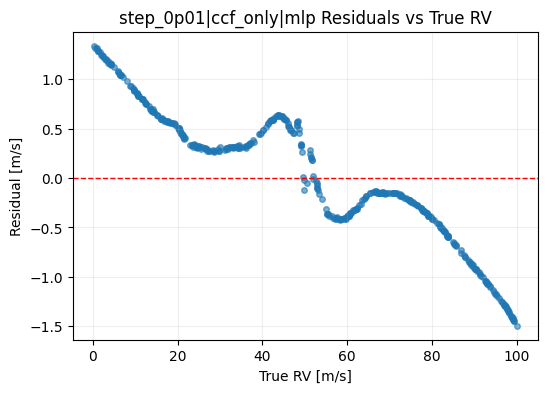

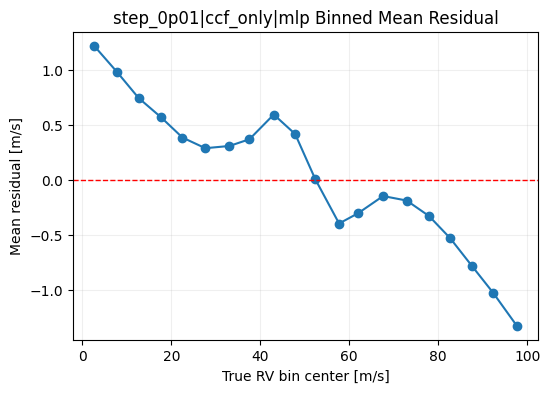

In [53]:
# ============================
# Compare / Inspect Best Runs
# ============================

display(results_df.sort_values("test_mae").head(10))

pivot = results_df.pivot_table(
    index=["dataset", "feature_mode"],
    columns="model",
    values="test_mae",
)
display(pivot)

# Inspect one run
if len(results_df):
    best = results_df.sort_values("test_mae").iloc[0]
    best_key = f"{best['dataset']}|{best['feature_mode']}|{best['model']}"
    print("Best run:", best_key)
    art = artifacts_map[best_key]
    plot_residuals_vs_rv(art, title_prefix=best_key)
    plot_binned_residuals(art, title_prefix=best_key)


In [54]:
# Inspect any trained model saved in artifacts_map
# Example key: "step_0p01|ccf_only|cnn_pooled"
if len(artifacts_map):
    some_key = list(artifacts_map.keys())[0]
    print("Example key:", some_key)
    m = artifacts_map[some_key]["model"]
    m.summary()
else:
    print("Run experiments first to populate artifacts_map.")


Example key: step_0p01|ccf_only|mlp


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 128)            │       384,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,177,733 (4.49 MB)

 Trainable params: 392,577 (1.50 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 785,156 (3.00 MB)